In [1]:
# clear all to reset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from datetime import datetime
from scipy import signal

os.system('clear')

1

In [2]:
#session 40

#aligned video (from camera not processed real-time)
df_v1 = pd.read_csv(r'C:\Users\fossati.veronica\Desktop\Regrasp_Project-master\Regrasp_Project-master\Code\mediapipe\Data\Session 40\2024-10-18-11-10-31_hand-tracking-landmarks1.csv')
#strat time file
f1 = r"C:\Users\fossati.veronica\Desktop\Regrasp_Project-master\Regrasp_Project-master\Code\mediapipe\Data\Session 40\2024-10-18-11-10-36-rec6-startTime.txt"
#stimulation file
f2 = r"C:\Users\fossati.veronica\Desktop\Regrasp_Project-master\Regrasp_Project-master\Code\mediapipe\Data\Session 40\2024-10-18-11-10-36-rec6_stimParams.txt"

#import stim time and parameters
with open(f1) as file:
    start_time = [line.rstrip() for line in file]
with open(f2) as file:
    stims = [line.rstrip() for line in file]
stim_events=[]
stim_type=[]

date_format = "%Y-%m-%d %H:%M:%S.%f"
for i_s,s in enumerate(stims):
    if 'min freq' in s:
        stim_events.append(f'{os.path.split(f1)[1][:10]} '+stims[i_s-1])
        stim_type.append('freq')
    elif 'min amp' in s:
        stim_events.append(f'{os.path.split(f1)[1][:10]} '+stims[i_s-1])
        stim_type.append('amp')

# Show the first few rows of the DataFrame
print(df_v1.head())


                    timestamp  landmark_index         x         y         z
0  2024-10-11 14:23:21.952100               0  0.407980  0.213789  0.000001
1  2024-10-11 14:23:21.952100               1  0.327492  0.224664 -0.081069
2  2024-10-11 14:23:21.952100               2  0.273508  0.265762 -0.134449
3  2024-10-11 14:23:21.952100               3  0.222000  0.304758 -0.180895
4  2024-10-11 14:23:21.952100               4  0.175421  0.312858 -0.226554


In [3]:
# Group by timestamp to process each frame separately
grouped_frames_v1 = df_v1.groupby('timestamp')
first_frame_v1 = grouped_frames_v1.get_group(df_v1['timestamp'].unique()[0])

In [4]:
# Function to calculate the angle between three points (landmarks)
def calculate_angle(a, b, c):
    # Ensure no None values are passed for the calculation
    if None in (a.iloc[0], a.iloc[1], a.iloc[2], b.iloc[0], b.iloc[1], b.iloc[2], c.iloc[0], c.iloc[1], c.iloc[2]):
        return None  # Return None or NaN if any coordinate is missing
    
    # Vector AB and BC
    v1 = np.array([a.iloc[0] - b.iloc[0], a.iloc[1] - b.iloc[1], a.iloc[2] - b.iloc[2]])  # Vector AB
    v2 = np.array([c.iloc[0] - b.iloc[0], c.iloc[1] - b.iloc[1], c.iloc[2] - b.iloc[2]])  # Vector BC

    # Dot product and magnitudes
    dot_product = np.dot(v1, v2)
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    # Avoid division by zero
    if magnitude_v1 == 0 or magnitude_v2 == 0:
        return None

    # Cosine of the angle between v1 and v2
    cos_angle = dot_product / (magnitude_v1 * magnitude_v2)

    # Return the angle in degrees
    angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))  # Ensure the value is in the range [-1, 1]
    return np.degrees(angle)


In [5]:
# Function to calculate the speed of landmarks (xyz) the hand
def calculate_speed(df):
    # Calculate the speed of each landmark (xyz) using the difference between consecutive frames
    speed = df[['x', 'y', 'z']].diff().abs()
    
    return speed


In [6]:
# Put the landmarks into marker_positions variable
marker_positions_v1 = df_v1[['x', 'y', 'z']].values

In [7]:
# Calculate the speed of the hand
speed_v1 = calculate_speed(first_frame_v1)

In [8]:
# Function to calculate angles for a frame
def calculate_finger_angles(frame):
    angles = {}
    
    # Safely retrieve landmarks and calculate angles
    def safe_loc(landmark_index):
        try:
            return frame.loc[landmark_index, ['x', 'y', 'z']]
        except KeyError:
            # If the landmark is missing, return a default value
            return pd.Series([None, None, None], index=['x', 'y', 'z'])

    # Thumb (landmarks 1-4)
    thumb_angle = calculate_angle(safe_loc(2), safe_loc(3), safe_loc(4))
    angles['Thumb'] = thumb_angle
    
    # Index finger (landmarks 5-8)
    index_angle = calculate_angle(safe_loc(5), safe_loc(6), safe_loc(7))
    angles['Index'] = index_angle
    
    # Middle finger (landmarks 9-12)
    middle_angle = calculate_angle(safe_loc(9), safe_loc(10), safe_loc(11))
    angles['Middle'] = middle_angle
    
    # Ring finger (landmarks 13-16)
    ring_angle = calculate_angle(safe_loc(13), safe_loc(14), safe_loc(15))
    angles['Ring'] = ring_angle
    
    # Pinky finger (landmarks 17-20)
    pinky_angle = calculate_angle(safe_loc(17), safe_loc(18), safe_loc(19))
    angles['Pinky'] = pinky_angle
    
    return angles

# Ensure the DataFrame has the proper index by unpacking the tuple
# grouped_frames contains (timestamp, frame) tuples, we only want to apply set_index to the frame
grouped_frames_v1 = [(timestamp, frame.set_index('landmark_index')) for timestamp, frame in grouped_frames_v1]

# Loop through frames and calculate angles for each frame
all_angles_v1 = {}
for timestamp, frame in grouped_frames_v1:
    all_angles_v1[timestamp] = calculate_finger_angles(frame)

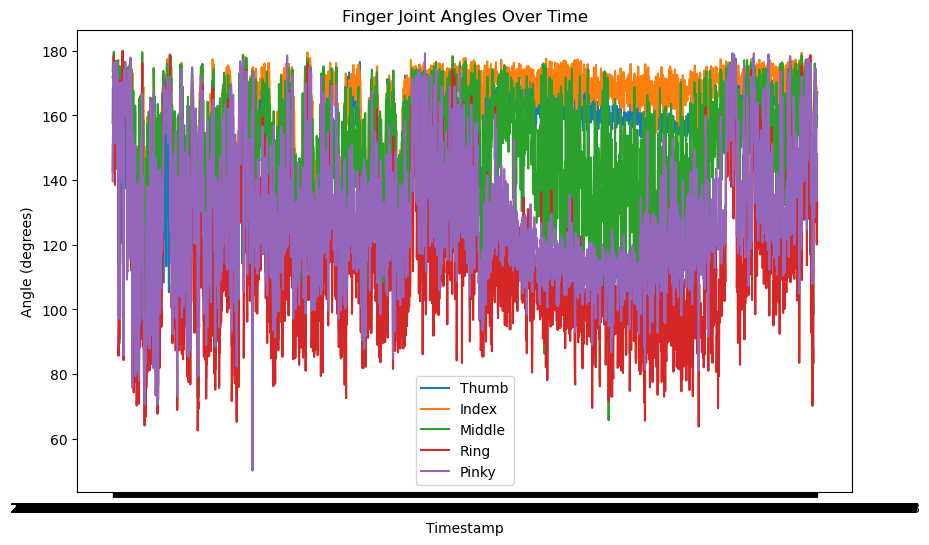

In [9]:
# Assuming all_angles and marker_positions are already defined
# all_angles: Dictionary of angles with timestamps as keys
# marker_positions: Dictionary of marker positions with timestamps as keys

# Convert angles data into a DataFrame
angles_df_v1 = pd.DataFrame(all_angles_v1).T  # Transpose to make timestamps the index

# Convert marker positions data into a DataFrame
marker_positions_df_v1 = pd.DataFrame(marker_positions_v1)  # Transpose to make timestamps the index

# Convert speed data into a DataFrame
speed_df_v1 = pd.DataFrame(speed_v1)  # Transpose to make timestamps the index


# Plot the angles over time
plt.figure(figsize=(10, 6))
for finger in angles_df_v1.columns:
    plt.plot(angles_df_v1.index, angles_df_v1[finger], label=finger)

plt.title('Finger Joint Angles Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Angle (degrees)')
plt.legend()
plt.show()

In [10]:
# Function to apply a low-pass filter
def low_pass_filter(data, cutoff=1, fs=30, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data, axis=0)
    return y

# Apply the low-pass filter to the marker positions
smoothed_marker_positions_v1 = low_pass_filter(marker_positions_df_v1.values)

# Apply the low-pass filter to the angles
smoothed_angles_v1 = angles_df_v1.apply(lambda x: low_pass_filter(x.values))

# Convert the smoothed data back to DataFrames
smoothed_marker_positions_df_v1 = pd.DataFrame(smoothed_marker_positions_v1, columns=marker_positions_df_v1.columns)
smoothed_angles_df_v1 = pd.DataFrame(smoothed_angles_v1, index=angles_df_v1.index, columns=angles_df_v1.columns)

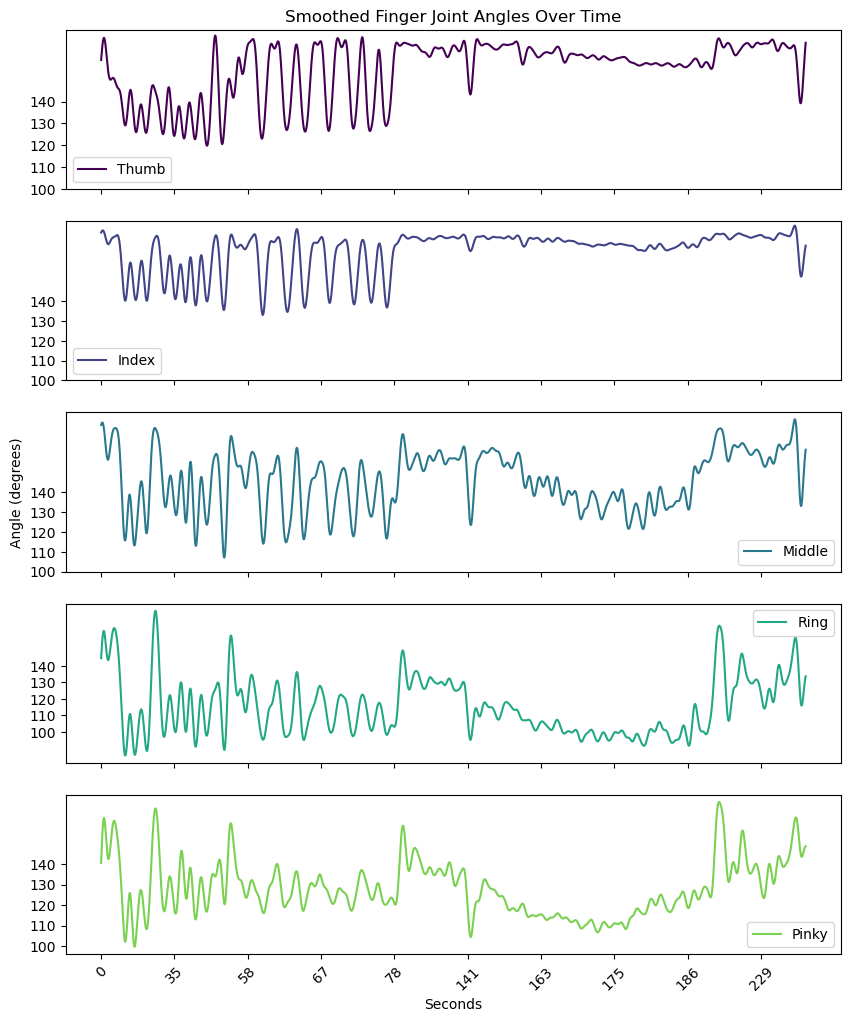

In [11]:
# Create subplots for each finger with gradient colors
fig, axs = plt.subplots(len(smoothed_angles_df_v1.columns), 1, figsize=(10, 12), sharex=True)

for i, finger in enumerate(smoothed_angles_df_v1.columns):
    color = plt.cm.viridis(i / len(smoothed_angles_df_v1.columns))  # Use a colormap for gradient colors
    axs[i].plot(smoothed_angles_df_v1.index, smoothed_angles_df_v1[finger], label=finger, color=color)
    axs[i].legend()
    # set xticks to show every 100th timestamp
    axs[i].set_xticks(smoothed_angles_df_v1.index[::250])
    # set yticks to show every 30 degrees
    axs[i].set_yticks(range(100, 150, 10))


# Show the title for the first subplot
axs[0].set_title('Smoothed Finger Joint Angles Over Time')
# Set the y-axis label for the 3rd subplot using angle
axs[2].set_ylabel('Angle (degrees)')
# Convert timestamp strings to datetime objects
smoothed_angles_df_v1.index = pd.to_datetime(smoothed_angles_df_v1.index, format='mixed')
start_timestamp_v1 = smoothed_angles_df_v1.index[0]

# Set xticks labels for the last subplot using start and end timestamps, converting to seconds starting from 0
axs[-1].set_xticklabels([round((timestamp - start_timestamp_v1).total_seconds()) for timestamp in smoothed_angles_df_v1.index[::250]], rotation=45)
# Set the x-axis label for the last subplot using timestamp
axs[-1].set_xlabel('Seconds')

plt.show()

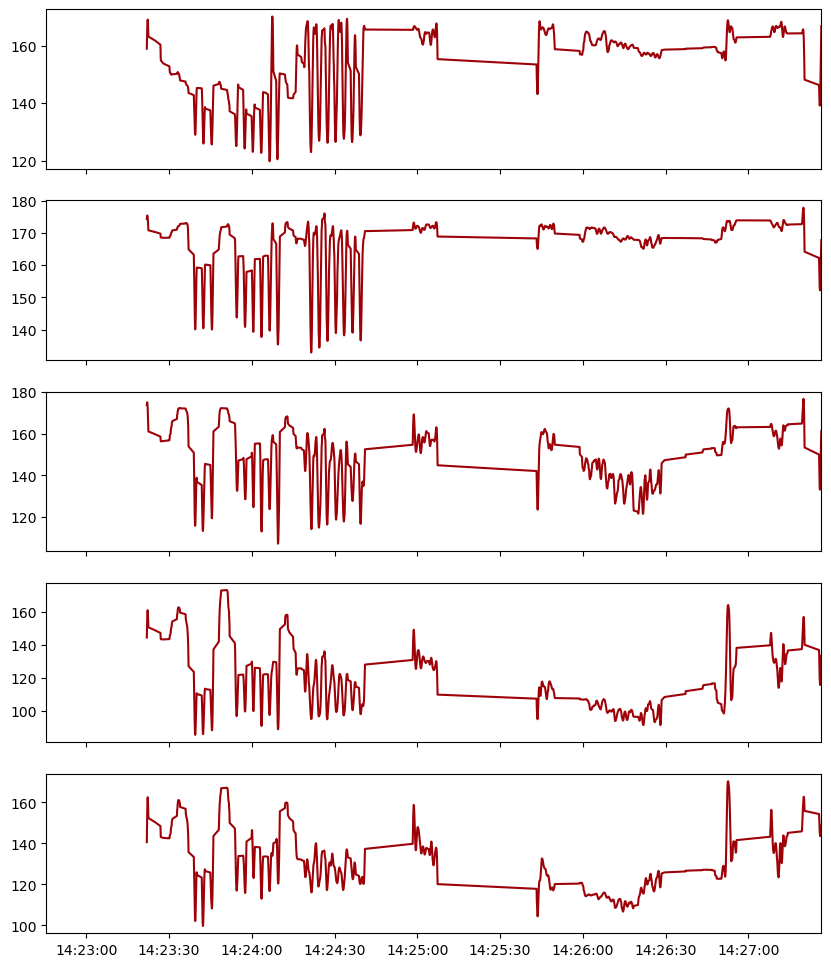

In [12]:
indexes=smoothed_angles_df_v1.index
signal_v1=smoothed_angles_df_v1[:]

fig, axs = plt.subplots(len(smoothed_angles_df_v1.columns), 1, figsize=(10, 12), sharex=True)
for i, finger in enumerate(smoothed_angles_df_v1.columns):
    color = plt.cm.viridis(i / len(smoothed_angles_df_v1.columns))  # Use a colormap for gradient colors
    axs[i].plot(indexes,signal_v1[finger], label=finger, color='#9d0208')
    axs[i].set_xlim((pd.Timestamp(stim_events[0]),indexes[-1]))


In [26]:
rec = os.path.split(f1)[1][20:24]
signal_v1.to_csv(os.path.split(f1)[0] + '/'+ 'kinematics_' + rec + '_v1_mod.csv')